1-Bibliotecas:

In [1]:
import scipy.io as io
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import amc_mlp_pipeline as mlp_pipe
import importlib
importlib.reload(mlp_pipe)

<module 'amc_mlp_pipeline' from 'c:\\Users\\felip\\Documents\\Mestrado-ITA\\ET-287\\ProjetoGrupo\\amc_mlp_pipeline.py'>

2-Carrega Base

In [2]:
path = r'C:\Users\felip\Documents\Mestrado-ITA\ET-287\ProjetoGrupo\dataset'

with h5py.File(os.path.join(path, 'X_train.mat'), 'r') as f:
    X_train = np.array(f['X_train'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_val.mat'), 'r') as f:
    X_val = np.array(f['X_val'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_test.mat'), 'r') as f:
    X_test = np.array(f['X_test'], dtype='float32').T

Y_train = io.loadmat(os.path.join(path, 'Y_train.mat'))['Y_train']
Y_val   = io.loadmat(os.path.join(path, 'Y_val.mat'))['Y_val']
Y_test  = io.loadmat(os.path.join(path, 'Y_test.mat'))['Y_test']

lbl_train = io.loadmat(os.path.join(path, 'lbl_train.mat'))['lbl_train']
lbl_val   = io.loadmat(os.path.join(path, 'lbl_val.mat'))['lbl_val']
lbl_test  = io.loadmat(os.path.join(path, 'lbl_test.mat'))['lbl_test']

In [3]:
print("Y_train shape:", Y_train.shape)
print("Y_train[:5]:", Y_train[:5])

print("lbl_train shape:", lbl_train.shape)
print("lbl_train[:5]:", lbl_train[:5])

Y_train shape: (469200, 23)
Y_train[:5]: [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
lbl_train shape: (469200, 6)
lbl_train[:5]: [[ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  4.22743774e-03
   1.28290481e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  2.00246104e-01
   7.98754715e-02  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  1.26933729e-01
   2.25750427e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.48238329e-02
   1.46626138e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.20988175e-02
   1.12184316e-01  0.00000000e+00]]


3-Define quais sinais modelar

In [4]:
idx_classes_paper = [0, 4, 5, 8, 10, 11, 12, 13, 14, 21, 22]

class_names_full = ['LFM', '2FSK', '4FSK', '8FSK', 'FM_Costas', '2PSK', '4PSK', '8PSK',
                    'PM_Barker', 'PM_Huffman', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3',
                    'PM_P4', 'PM_Px', 'PM_ZadoffChu', 'PM_T1', 'PM_T2', 'PM_T3', 'PM_T4', 'NM', 'Noise']

classes_paper = [class_names_full[i] for i in idx_classes_paper]
print(classes_paper)

['LFM', 'FM_Costas', '2PSK', 'PM_Barker', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3', 'PM_P4', 'NM', 'Noise']


4-Filtra Base com Sinais Selecionados

In [5]:
y_idx_train = np.argmax(Y_train, axis=1)
y_idx_val   = np.argmax(Y_val, axis=1)
y_idx_test  = np.argmax(Y_test, axis=1)

# 1) Cria máscara para as 11 classes do paper
mask_train = np.isin(y_idx_train, idx_classes_paper)
mask_val   = np.isin(y_idx_val, idx_classes_paper)
mask_test  = np.isin(y_idx_test, idx_classes_paper)

# 2) Filtra
X_train_f, Y_train_f, lbl_train_f = X_train[mask_train], Y_train[mask_train], lbl_train[mask_train]
X_val_f,   Y_val_f,   lbl_val_f   = X_val[mask_val],     Y_val[mask_val],     lbl_val[mask_val]
X_test_f,  Y_test_f,  lbl_test_f  = X_test[mask_test],   Y_test[mask_test],   lbl_test[mask_test]

print("Treino:", X_train.shape, "->", X_train_f.shape)
print("Validação:", X_val.shape, "->", X_val_f.shape)
print("Teste:", X_test.shape, "->", X_test_f.shape)

# 3) Libera memória do que não precisa mais
import gc
del X_train, X_val, X_test, Y_train, Y_val, Y_test
gc.collect()

Treino: (469200, 1024, 2) -> (224400, 1024, 2)
Validação: (156400, 1024, 2) -> (74800, 1024, 2)
Teste: (156400, 1024, 2) -> (74800, 1024, 2)


0

In [6]:
# Re-mapear os rótulos para 0–10
remap = {old: new for new, old in enumerate(idx_classes_paper)}

y_idx_train_f = np.array([remap[c] for c in y_idx_train[mask_train]])
y_idx_val_f   = np.array([remap[c] for c in y_idx_val[mask_val]])
y_idx_test_f  = np.array([remap[c] for c in y_idx_test[mask_test]])

# One-hot para 11 classes
from tensorflow.keras.utils import to_categorical
Y_train_f = to_categorical(y_idx_train_f, num_classes=11)
Y_val_f   = to_categorical(y_idx_val_f, num_classes=11)
Y_test_f  = to_categorical(y_idx_test_f, num_classes=11)


--- Estatísticas básicas por classe ---
Classe             Média I      Std I    Média Q      Std Q
LFM                -0.0001     0.3881     0.0002     0.3880
FM_Costas          -0.0000     0.3720     0.0010     0.3713
2PSK                0.0000     0.3882    -0.0002     0.3879
PM_Barker          -0.0070     0.3905    -0.0004     0.3878
PM_Frank            0.0024     0.3695     0.0003     0.3685
PM_P1               0.0022     0.3695     0.0001     0.3687
PM_P2              -0.0012     0.3698    -0.0007     0.3691
PM_P3               0.0023     0.3694    -0.0001     0.3683
PM_P4               0.0022     0.3693    -0.0002     0.3686
NM                  0.0002     0.3882    -0.0001     0.3881
Noise               0.0001     0.2613     0.0000     0.2613

--- Gerando gráficos de EDA ---


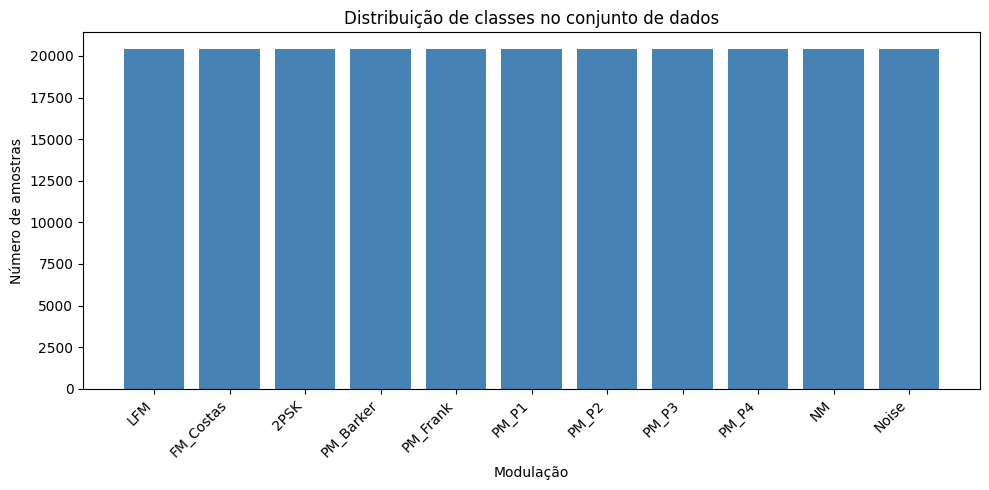

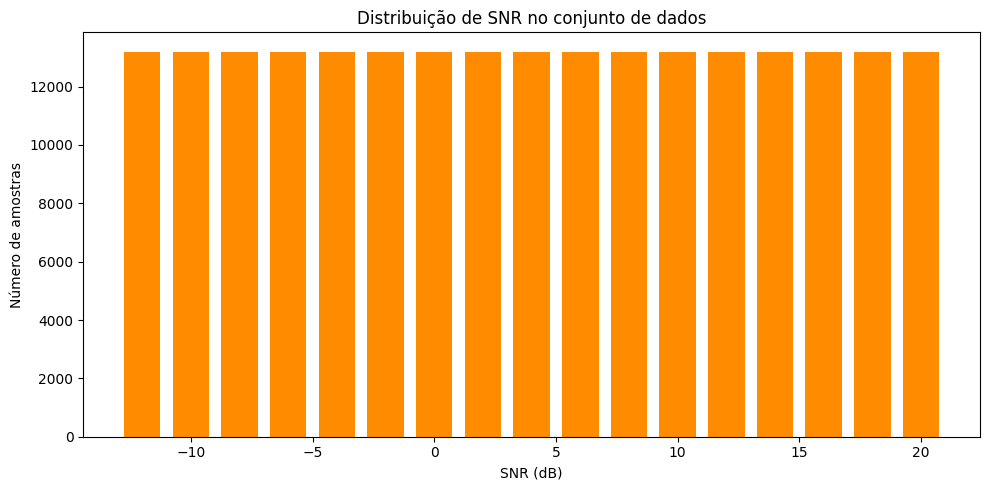

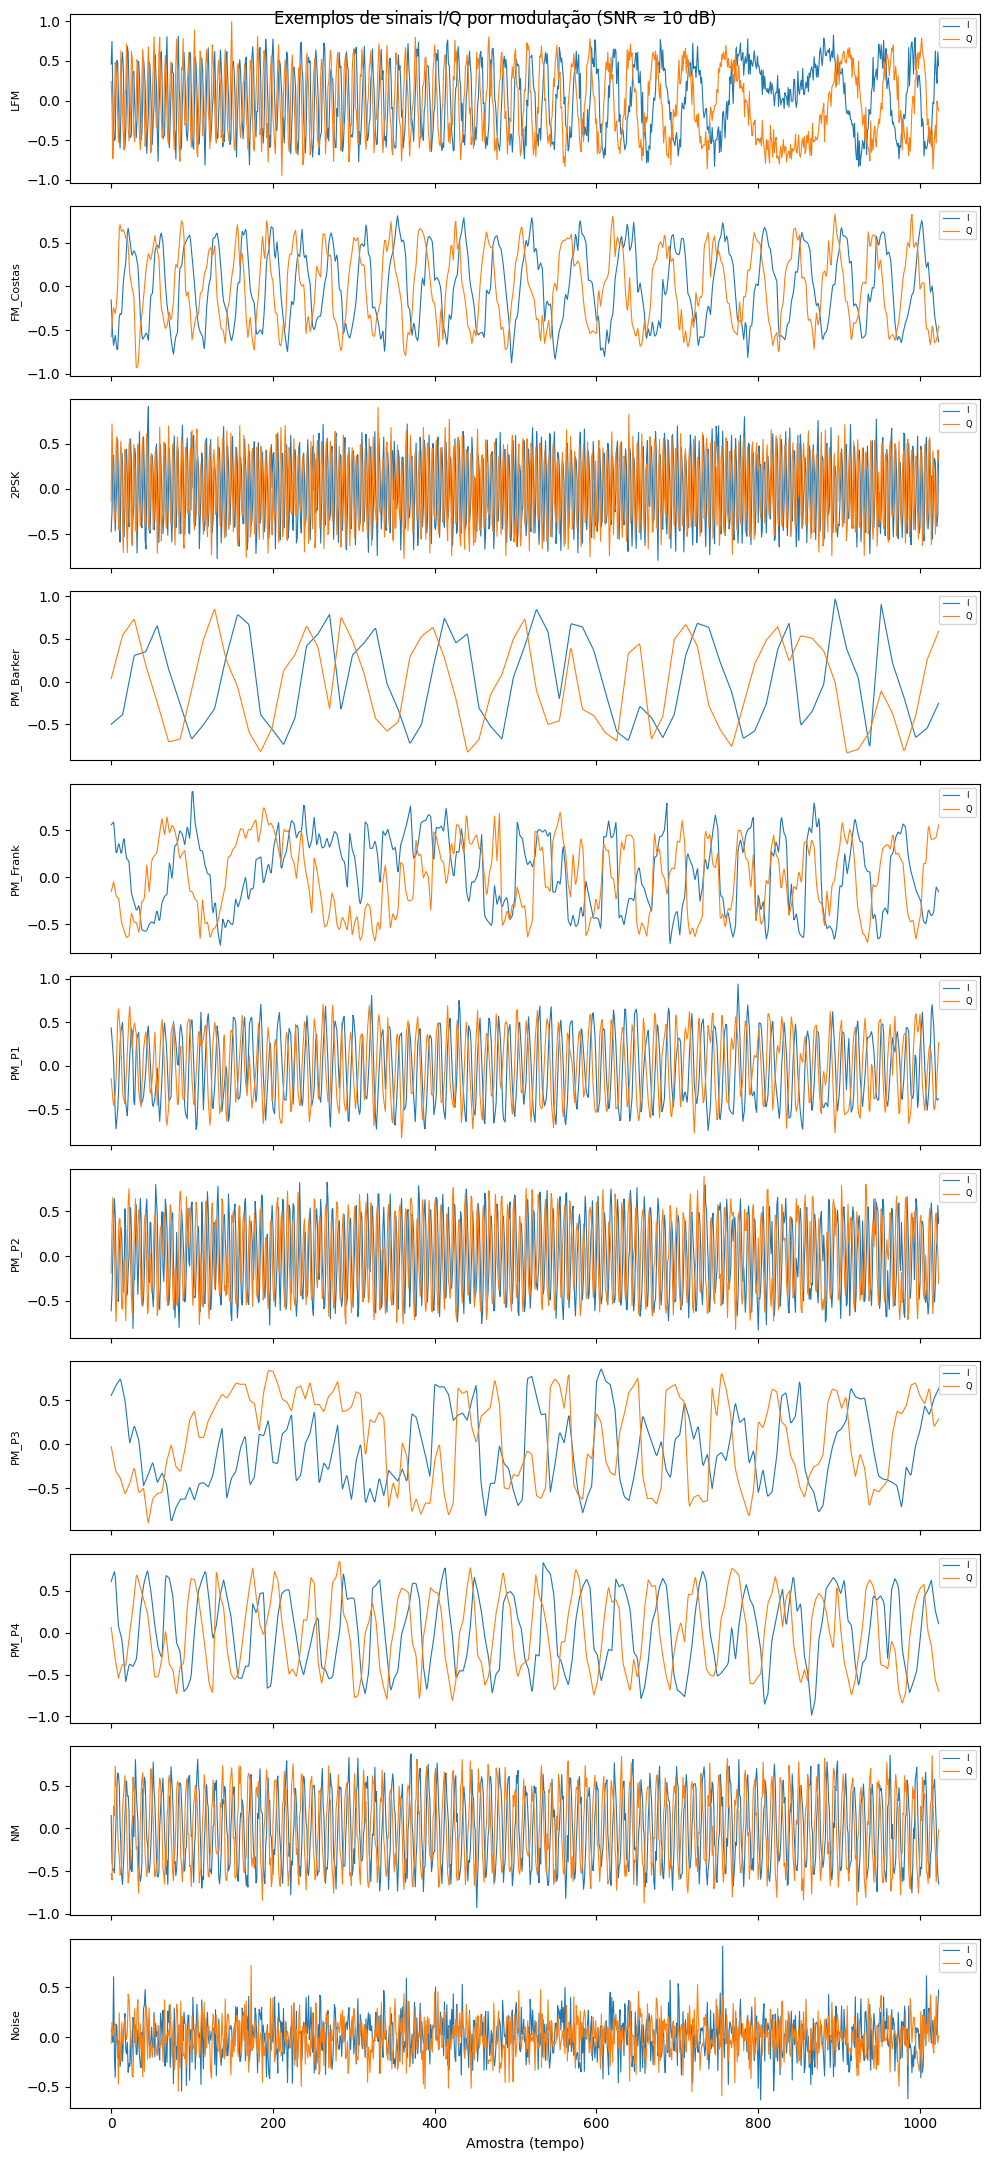

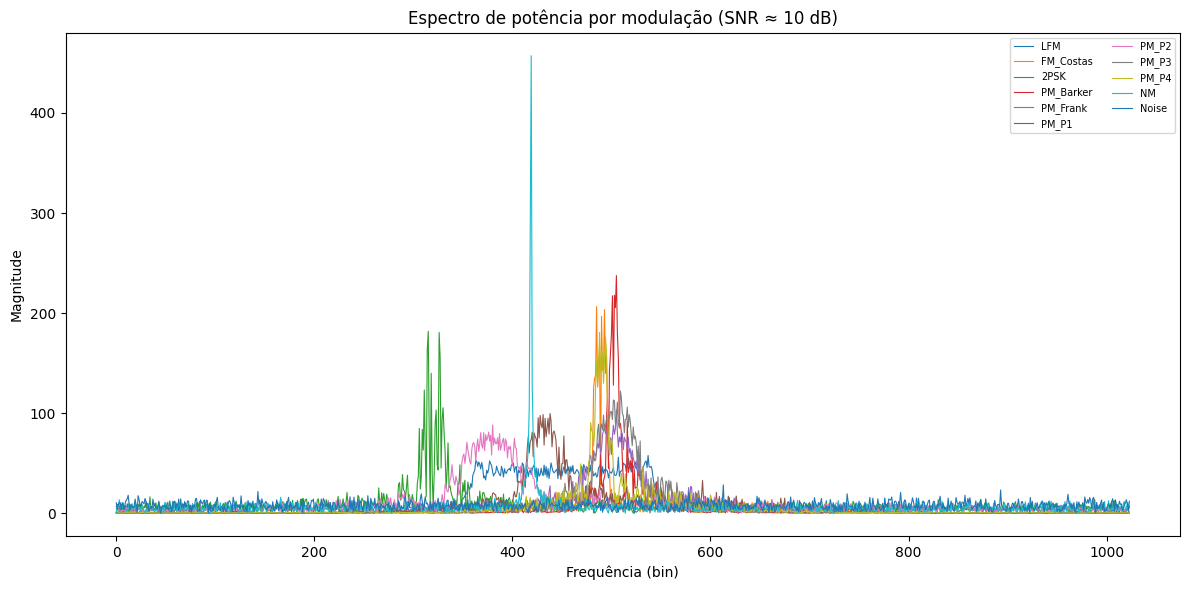

In [7]:
snr_train_f = lbl_train_f[:, 1].astype(int)

mlp_pipe.run_eda(X_train_f, y_idx_train_f, snr_train_f)

In [8]:
# 1) Extrai features do sinal BRUTO (não do achatado!)
X_train_feat = mlp_pipe.extract_features(X_train_f)
X_val_feat   = mlp_pipe.extract_features(X_val_f)
X_test_feat  = mlp_pipe.extract_features(X_test_f)

# 2) Normaliza com estatísticas do treino
mean, std = mlp_pipe.compute_normalization_stats(X_train_feat)
X_train_norm = mlp_pipe.normalize(X_train_feat, mean, std)
X_val_norm   = mlp_pipe.normalize(X_val_feat, mean, std)
X_test_norm  = mlp_pipe.normalize(X_test_feat, mean, std)

# 3) Treina (class_weight já entra por padrão)
model, history = mlp_pipe.train_mlp(
    X_train_norm, y_idx_train_f,
    X_val_norm, y_idx_val_f,
    input_dim=X_train_norm.shape[1]
)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0}
Epoch 1/100
877/877 - 42s - 48ms/step - accuracy: 0.1000 - loss: 3.3071 - val_accuracy: 0.1100 - val_loss: 2.6720
Epoch 2/100
877/877 - 21s - 24ms/step - accuracy: 0.4688 - loss: 1.4300 - val_accuracy: 0.6075 - val_loss: 0.9328
Epoch 3/100
877/877 - 21s - 24ms/step - accuracy: 0.5994 - loss: 0.9528 - val_accuracy: 0.6748 - val_loss: 0.7526
Epoch 4/100
877/877 - 22s - 26ms/step - accuracy: 0.6572 - loss: 0.7851 - val_accuracy: 0.7053 - val_loss: 0.6624
Epoch 5/100
877/877 - 20s - 23ms/step - accuracy: 0.6936 - loss: 0.6947 - val_accuracy: 0.7246 - val_loss: 0.6340
Epoch 6/100
877/877 - 46s - 53ms/step - accuracy: 0.7179 - loss: 0.6384 - val_accuracy: 0.7280 - val_loss: 0.6070
Epoch 7/100
877/877 - 39s - 44ms/step - accuracy: 0.7329 - loss: 0.6025 - val_accuracy: 0.7334 - val_loss: 0.6087
Epoch 8/100
877/877 - 22s - 25ms/step - accuracy: 0.7412 - loss: 0.5787 - val_accuracy: 0.7435 - 


Acurácia geral no teste: 80.15%

              precision    recall  f1-score   support

         LFM     0.9096    0.8896    0.8995      6800
   FM_Costas     0.9510    0.9538    0.9524      6800
        2PSK     0.9086    0.8591    0.8831      6800
   PM_Barker     0.9720    0.9697    0.9708      6800
    PM_Frank     0.6703    0.7112    0.6901      6800
       PM_P1     0.6518    0.5147    0.5752      6800
       PM_P2     0.5498    0.7056    0.6180      6800
       PM_P3     0.7083    0.7032    0.7058      6800
       PM_P4     0.6275    0.5487    0.5854      6800
          NM     0.9895    0.9984    0.9939      6800
       Noise     0.9035    0.9628    0.9322      6800

    accuracy                         0.8015     74800
   macro avg     0.8038    0.8015    0.8006     74800
weighted avg     0.8038    0.8015    0.8006     74800



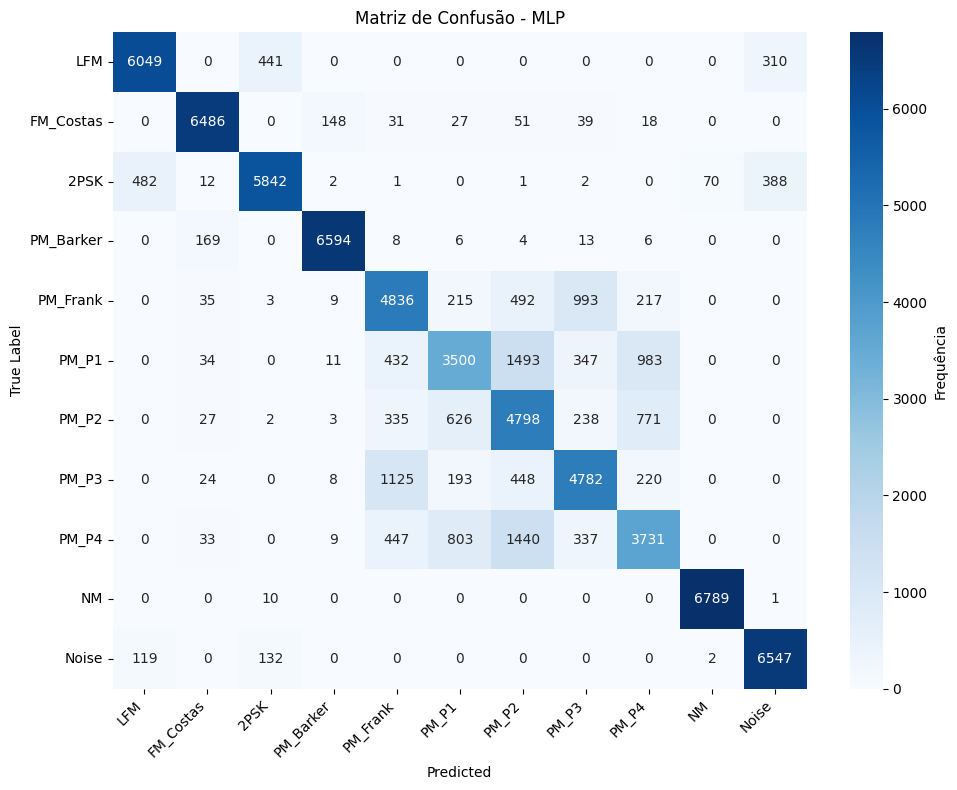

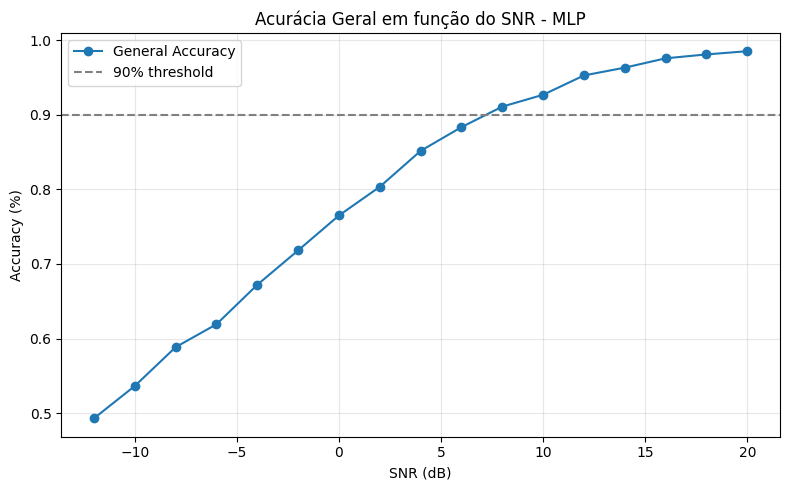

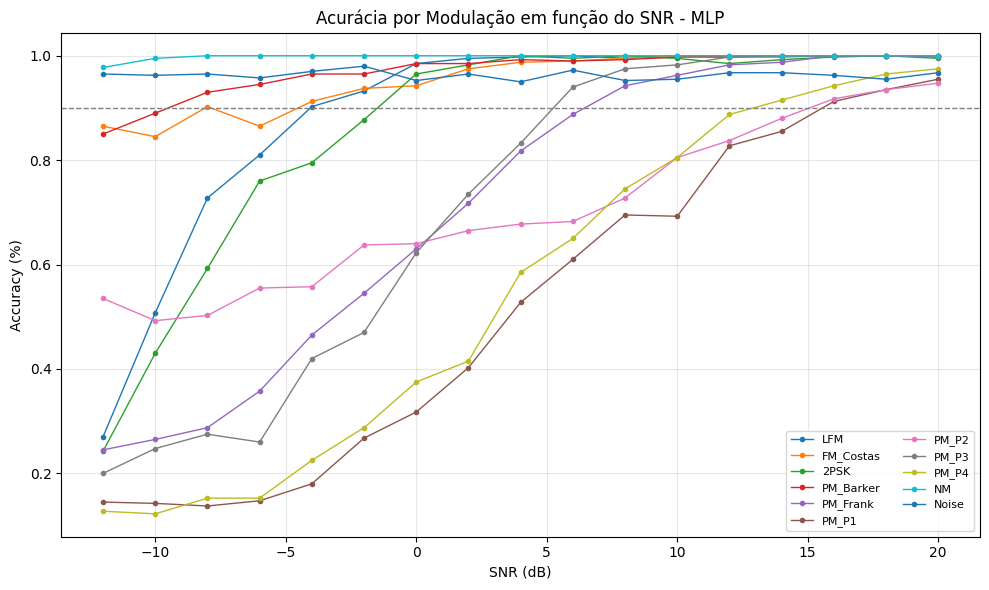


SNR mínimo (geral) para 90% de acurácia: 8 dB
SNR mínimo por modulação: {'LFM': -4, 'FM_Costas': -4, '2PSK': 0, 'PM_Barker': -8, 'PM_Frank': 8, 'PM_P1': 16, 'PM_P2': 16, 'PM_P3': 6, 'PM_P4': 14, 'NM': -12, 'Noise': -12}
Modulação limitante: PM_P1 (16 dB)


In [9]:
X_test_feat = mlp_pipe.extract_features(X_test_f)
X_test_norm = mlp_pipe.normalize(X_test_feat, mean, std)
snr_test_f = lbl_test_f[:, 1].astype(int)

results = mlp_pipe.run_evaluation(model, X_test_norm, y_idx_test_f, snr_test_f)